# Import datasets

In [2]:
import pandas as pd
df = pd.read_csv('lazada_products_raw.csv')
# print(df.head())

# Xử lý dữ liệu

## Xử lý cột "discount"

In [3]:
# Trích số % từ cột discount, nếu không có thì gán là 0
df['discount'] = df['discount'].str.extract(r'(\d+)', expand=False)
df['discount'] = df['discount'].fillna(0).astype(int)

# print(df.head())

## Xử lý cột "price"

In [4]:
# Làm sạch và chuyển giá sang số nguyên
df['price'] = df['price'].str.replace(r'[^\d]', '', regex=True).astype(int)

print(df.head())

                                                 url  \
0  https://www.lazada.vn/products/pdp-i3106405420...   
1  https://www.lazada.vn/products/pdp-i3106402147...   
2  https://www.lazada.vn/products/pdp-i3105282159...   
3  https://www.lazada.vn/products/pdp-i3105146001...   
4  https://www.lazada.vn/products/pdp-i3105144009...   

                                                name  discount    price  \
0  Điện Thoại Samsung Galaxy A15 (8GB/256GB) Chín...        33  3799000   
1  Điện thoại Samsung A06 5G Chính hãng Samsung V...         0  2590000   
2  Điện thoại Samsung Galaxy A33 máy 2sim ram 6G/...         0  2800000   
3  [Chính hãng] Điện thoại Opp0 FFIND N5 (16GB/51...        50  1600000   
4  điện thoại 0PP0 A57 (128GB) | Cấu hình Cao Chi...        50   730000   

   location                                          image_url  
0    Hà Nội  https://img.lazcdn.com/g/p/0b8f95d0b16f890a952...  
1    Hà Nội  https://img.lazcdn.com/g/p/8fca1260ff930023bbc...  
2  Bạc Liêu  http

## Xử lý cột "name"

In [5]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from collections import defaultdict

In [6]:
# Bước 1: Chuẩn hóa cơ bản
def preprocess_text(text):
    # Chuẩn hóa các thương hiệu phổ biến
    replacements = {
        r'0PP0': 'OPPO ',
        r'Opp0': 'OPPO ',
        r'OPPO\s*': 'OPPO ',
        r'Viv0': 'Vivo ',
        r'Vivo\s*': 'Vivo ',
        r'ss': 'Samsung ',
        r'Ss': 'Samsung ',
        r'SS': 'Samsung ',
        r'SS_': 'Samsung ',
        r'Samsung\s*': 'Samsung ',
        r'Apple\s*': 'Apple ',
        r'Redmi_n0te': 'Redmi Note ',
        r'Red\.mi': 'Redmi ',
        r'P0c0': 'POCO ',
        r'mi Mi': 'Xiaomi ',
        r'pr0': 'Pro ',
        r'pro\s*': 'Pro ',
        r'f0ld': 'Fold ',

    }
    
    for pattern, replacement in replacements.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    
    # Loại bỏ các ký tự đặc biệt không cần thiết
    text = re.sub(r'[^\w\s/]', ' ', text)       # Loại bỏ ký tự đặc biệt (giữ lại chữ, số, _, /)
    text = re.sub(r'[_+=-]', ' ', text)         # Loại riêng các ký tự không mong muốn như _, +, =, -
    text = re.sub(r'\s+', ' ', text).strip()    # Rút gọn khoảng trắng dư thừa
    
    return text

df['cleaned_name'] = df['name'].apply(preprocess_text)
print(df['cleaned_name'].head())
df.to_csv('cleaned_phone_products.csv', index=False)

0    Điện Thoại Samsung Galaxy A15 8GB/256GB Chính ...
1    Điện thoại Samsung A06 5G Chính hãng Samsung V...
2    Điện thoại Samsung Galaxy A33 máy 2sim ram 6G/...
3    Chính hãng Điện thoại OPPO FFIND N5 16GB/512GB...
4    điện thoại OPPO A57 128GB Cấu hình Cao Chiến m...
Name: cleaned_name, dtype: object


In [7]:
# Bước 2: Trích xuất thông số kỹ thuật và bảo hành
def extract_specs(text):
    specs = {
        'ram': None,
        'rom': None,
        'battery': None,
        'network': None,
        'sim': None
    }
    
    # Trích xuất RAM/ROM
    ram_rom_match = re.search(r'(\d+GB)\s*[/-]\s*(\d+GB)', text, re.IGNORECASE)
    if ram_rom_match:
        specs['ram'], specs['rom'] = ram_rom_match.groups()
    
    # Trích xuất dung lượng pin
    battery_match = re.search(r'pin\s*(\d+\s*mAh)', text, re.IGNORECASE)
    if battery_match:
        specs['battery'] = battery_match.group(1)
    
    # Trích xuất thông tin mạng
    if '5G' in text:
        specs['network'] = '5G'
    
    # Trích xuất thông tin sim
    sim_match = re.search(r'(\d+)sim', text, re.IGNORECASE)
    if sim_match:
        specs['sim'] = sim_match.group(1)
    
    return specs

def extract_warranty(text):
    match = re.search(r'(\d+)\s*tháng', text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1))
    match = re.search(r'(\d+)\s*năm', text, flags=re.IGNORECASE)
    if match:
        return int(match.group(1)) * 12
    return 0

# Áp dụng hàm trích xuất
specs_df = df['cleaned_name'].apply(lambda x: pd.Series(extract_specs(x)))
df['warranty_months'] = df['cleaned_name'].apply(extract_warranty)
df = pd.concat([df, specs_df], axis=1)

In [ ]:
import re

brands = ['Samsung', 'OPPO', 'Xiaomi', 'Redmi', 'POCO', 'Vivo', 'HONOR', 'ZTE', 'Nubia', 'Realme']
stop_words = ['chính', 'ram', 'rom', 'full', 'seal', 'bản', 'hãng', 'mới', '100', 'cấu', 'hình', 'pin', 'máy', 'bảo', 'hành', 'hàng', 'bh']
ram_rom_pattern = re.compile(r'^\d+(gb|g)$', re.IGNORECASE)

def detect_brand(text):
    text = text.lower()
    for brand in brands:
        if brand.lower() in text:
            return brand
    return 'Unknown'

def extract_model(text, brand):
    if brand == 'Unknown':
        return None
    text = text.lower()

    # Làm sạch ký tự đặc biệt như -, _, +, =
    text = re.sub(r'[^\w\s/]', ' ', text)
    text = re.sub(r'[_+=-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # Tìm cụm từ sau brand, tối đa 5 từ
    pattern = re.compile(rf'{brand.lower()}\s+((?:[a-z0-9]+\s*){{1,5}})', re.IGNORECASE)
    match = pattern.search(text)
    if match:
        model_raw = match.group(1).strip()
        tokens = model_raw.split()

        # Lọc stop words và các token chứa RAM/ROM
        clean_tokens = []
        for token in tokens:
            if token.lower() in stop_words or ram_rom_pattern.match(token):
                break
            clean_tokens.append(token)

        if not clean_tokens:
            return None

        # Lấy tối đa 2 từ đầu tiên
        return ' '.join(clean_tokens[:3])

    return None

# Áp dụng vào DataFrame
df['brand'] = df['cleaned_name'].apply(detect_brand)
df['model'] = df.apply(lambda row: extract_model(row['cleaned_name'], row['brand']), axis=1)


In [9]:
# Bước 4: Làm sạch final
def clean_model_name(model):
    if pd.isna(model):
        return model
    # Loại bỏ thông số kỹ thuật nằm trong tên model
    model = re.sub(r'\d+\s*GB', '', model, flags=re.IGNORECASE)
    model = re.sub(r'pin\s*\d+\s*mAh', '', model, flags=re.IGNORECASE)
    model = re.sub(r'\d+\s*sim', '', model, flags=re.IGNORECASE)
    model = re.sub(r'\b5G\b', '', model, flags=re.IGNORECASE)

    # Chuẩn hoá khoảng trắng
    model = re.sub(r'\s+', ' ', model).strip()
    return model

df['model'] = df['model'].apply(clean_model_name)

# Chọn các cột quan trọng cho output
clean_df = df[['url', 'brand', 'model', 'ram', 'rom', 'battery', 'network', 'sim', 'warranty_months', 'discount', 'price', 'location', 'image_url']]
# Lưu kết quả vào file CSV
clean_df.to_csv('final_cleaned_phone_products.csv', index=False)

# Trực quan hoá dữ liệu

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load dữ liệu
df = pd.read_csv("final_cleaned_phone_products.csv")

# Chuyển các cột số sang định dạng số (bỏ giá trị rỗng)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['warranty_months'] = pd.to_numeric(df['warranty_months'], errors='coerce')


## Biểu đồ số lượng sản phẩm theo hãng (brand)

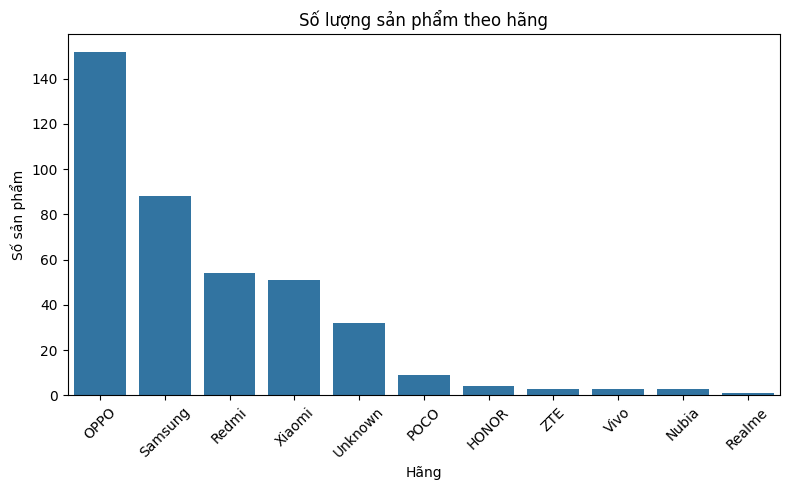

In [2]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='brand', order=df['brand'].value_counts().index)
plt.title("Số lượng sản phẩm theo hãng")
plt.xlabel("Hãng")
plt.ylabel("Số sản phẩm")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Biểu đồ giá trung bình theo hãng

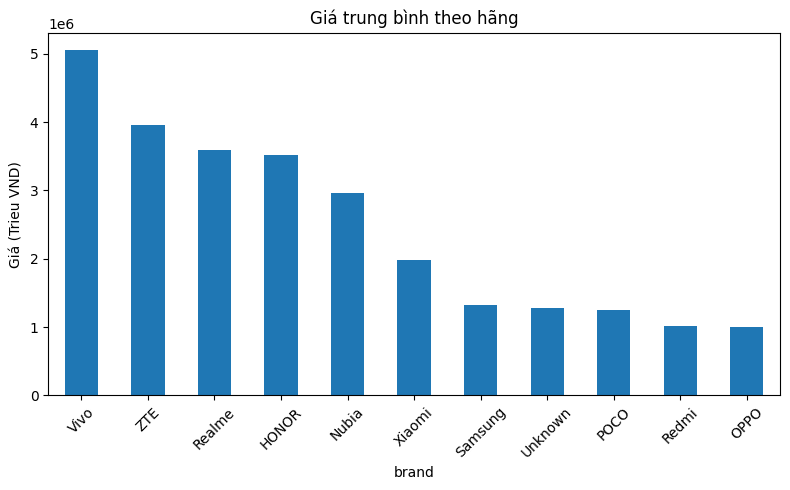

In [4]:
avg_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
avg_price.plot(kind='bar', figsize=(8,5), title='Giá trung bình theo hãng')
plt.ylabel('Giá (Trieu VND)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Biểu đồ phân phối mức giảm giá

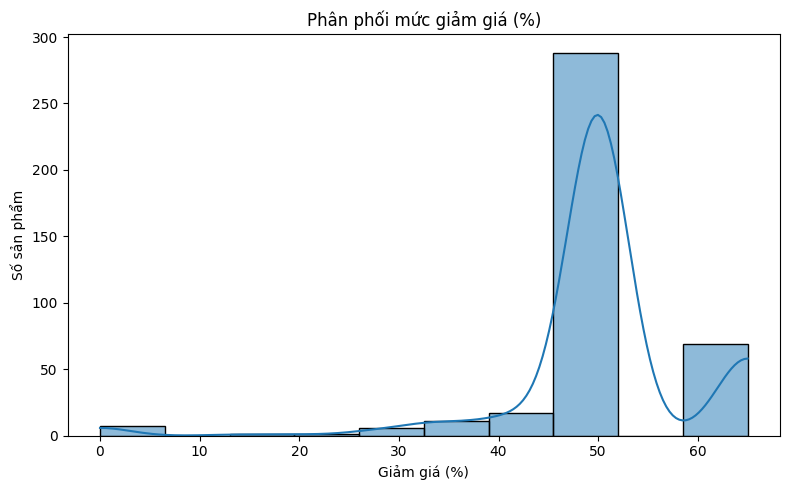

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df['discount'], bins=10, kde=True)
plt.title("Phân phối mức giảm giá (%)")
plt.xlabel("Giảm giá (%)")
plt.ylabel("Số sản phẩm")
plt.tight_layout()
plt.show()


## Biểu đồ boxplot giá theo từng hãng

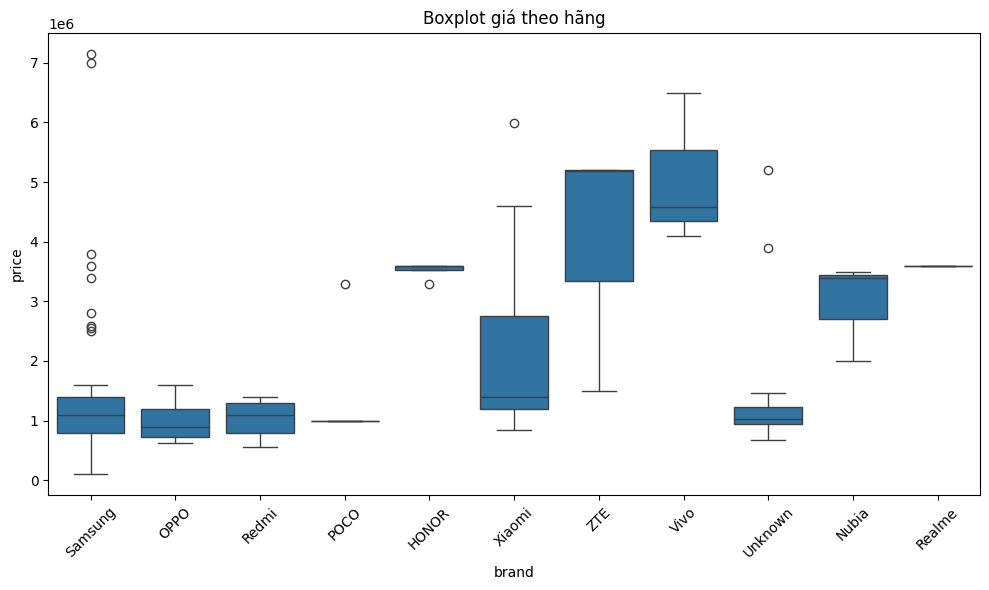

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='brand', y='price')
plt.title("Boxplot giá theo hãng")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Số sản phẩm theo khu vực

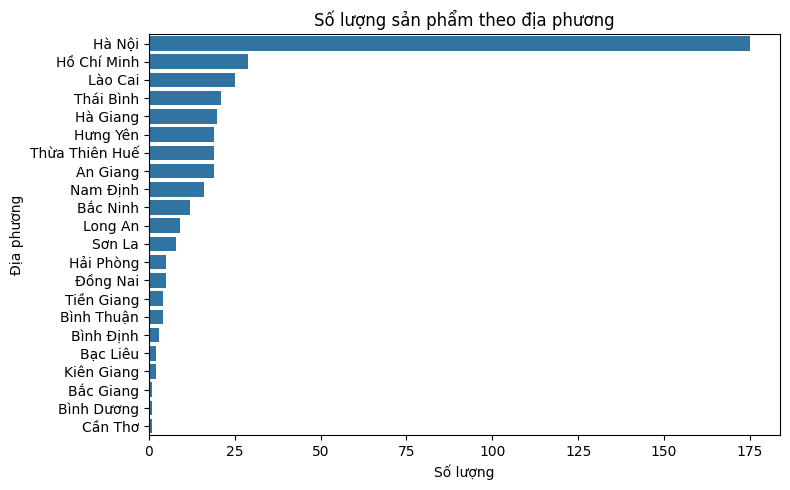

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, y='location', order=df['location'].value_counts().index)
plt.title("Số lượng sản phẩm theo địa phương")
plt.xlabel("Số lượng")
plt.ylabel("Địa phương")
plt.tight_layout()
plt.show()


## Biểu đồ scatter: Giá vs RAM

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mayti\AppData\Local\Temp\ipykernel_9980\3461811355.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['ram_num'] = df['ram'].str.extract('(\d+)').astype(float)


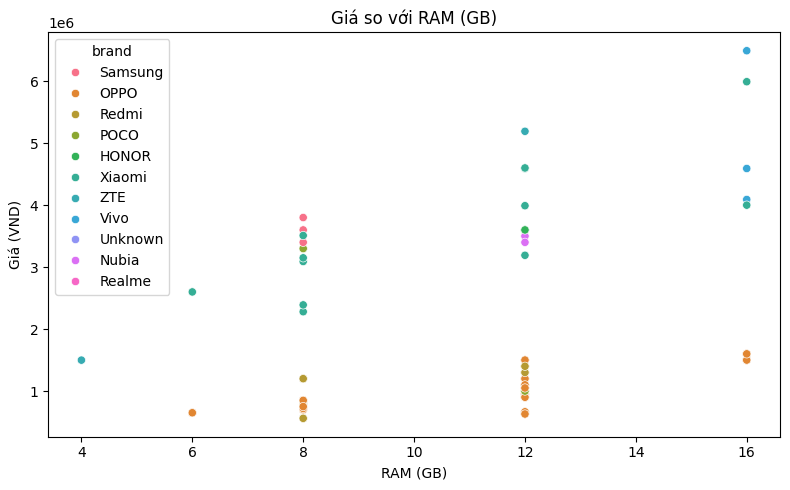

In [8]:
# Chuyển RAM thành số (nếu có GB)
df['ram_num'] = df['ram'].str.extract('(\d+)').astype(float)

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='ram_num', y='price', hue='brand')
plt.title("Giá so với RAM (GB)")
plt.xlabel("RAM (GB)")
plt.ylabel("Giá (VND)")
plt.tight_layout()
plt.show()


## Treemap: Hãng và số lượng sản phẩm

In [13]:
fig = px.treemap(df, path=['brand'], title="Tỉ lệ sản phẩm theo hãng")
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Biểu đồ heatmap: Mối liên hệ giữa RAM, ROM và giá

<>:1: SyntaxWarning:

invalid escape sequence '\d'

<>:1: SyntaxWarning:

invalid escape sequence '\d'

C:\Users\mayti\AppData\Local\Temp\ipykernel_9980\613598793.py:1: SyntaxWarning:

invalid escape sequence '\d'



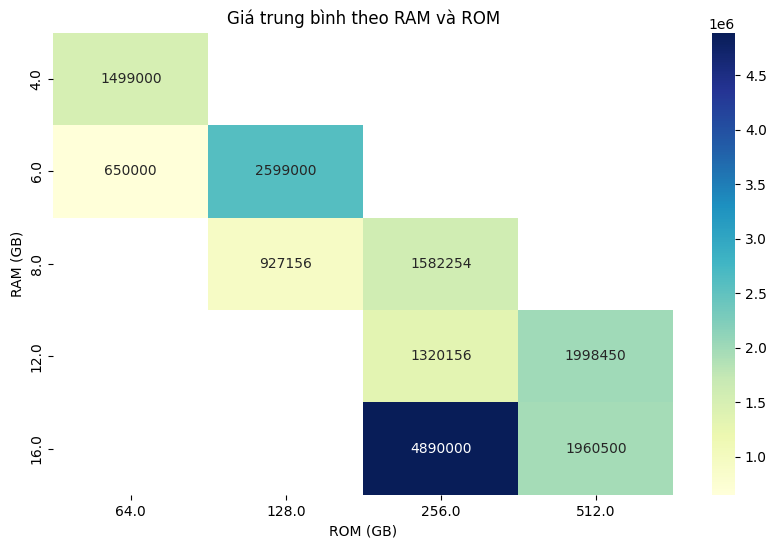

In [11]:
df['rom_num'] = df['rom'].str.extract('(\d+)').astype(float)
pivot_table = df.pivot_table(index='ram_num', columns='rom_num', values='price', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Giá trung bình theo RAM và ROM")
plt.xlabel("ROM (GB)")
plt.ylabel("RAM (GB)")
plt.show()
